# radflux_clearsky

## The script

In [143]:
import surfradpy.scripts.clamps3_radflux_clearsky as srfcsrc

In [175]:
reload(srfcsrc)

<module 'surfradpy.scripts.clamps3_surfrad_radflux_clearsky' from '/Users/htelg/prog/SURFRAD/surfradpy/scripts/clamps3_surfrad_radflux_clearsky.py'>

In [176]:
out = srfcsrc.run(prefix='/Volumes',start = '2025-09-02', days = None, test = 2, log_folder=None, verbose=True)

start surfrad_radflux_clearsky
start time: 2026-10-09 13:12:59.348999


Get all files in /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/netcdf/radiation/v1.1 with "files_between" function and start: 2025-09-02 00:00:00, end: 2026-10-09 13:12:59.447146 and file_name_format: *{date:%Y%m%d}*


workplan.shape: (336, 1)


setting new variable maximum_solar_zenith_angle to 90.0
setting new variable maximum_diffuse_shortwave_irradiance to 150.0
setting new variable maximum_diffuse_shortwave_cosine_exponent to 0.5
setting new variable normalized_diffuse_ratio_standard_deviation_limit to 0.001
Casting normalized diffuse ratio standard deviation window to int
setting new variable normalized_diffuse_ratio_standard_deviation_window_minutes to 11
setting new variable shortwave_temporal_gradient_envelope_constant to 2.0
setting new variable minimum_total_shortwave_irradiance to 1.0
setting new variable normalized_total_shortwave_intermediate_iteration_half_width to 150.0
setting new variable normalized_total_shortwave_final_iteration_half_width to 100.0
setting new variable normalized_total_shortwave_low_sun_cosine_boundary to 0.2
setting new variable minimum_clear_sky_duration_for_daily_fit to 110
setting new variable diffuse_ratio_exponent_lower_validity_limit to -0.95
setting new variable diffuse_ratio_expone

No log file specified, skipping logging.


## the product

In [5]:
import surfradpy.products.radflux as srfrf

In [6]:
import atmPy.general.measurement_site as atmms

In [7]:
plt.rcParams['figure.dpi'] = 300

In [8]:
parent = srfrf.RadfluxClearskyParameterAnalysis.__mro__[1]
parent

productomator.worker.Workplanner

In [134]:
reload(srfrf.prowo)
reload(srfrf)

<module 'surfradpy.products.radflux' from '/Users/htelg/prog/SURFRAD/surfradpy/products/radflux.py'>

In [153]:
site = atmms.Station(lat=39.94713, lon = -105.19635, alt = 1742.04, name = 'clamps3 at Marshall', abbreviation='clamps3', state = 'CO')
p2fld_in = '/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/netcdf/radiation/v1.1/'
radflux_parameters_db = f'radflux_params.db'
path2raflux_setting = f'radflux_settings.toml'
self = srfrf.RadfluxClearskyParameterAnalysis_Clamps3(
    p2fld_in=p2fld_in,
    p2fld_out=None,
    database=None,
    file_name_format='*{date:%Y%m%d}*',
    output_file_format=None,
    start=None,
    end=None,
    days = 500,
    input_directory_structure='yearly',
    output_directory_structure=None,
    file_complete_check=False,
    reporter=None,
    verbose=True,
    radflux_parameters_db = radflux_parameters_db,
    path2raflux_setting = path2raflux_setting,
    site = site
)
# self.masterplan
self.workplan

start time: 2026-10-09 13:06:04.751778
Get all files in /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/netcdf/radiation/v1.1 with "files_between" function and start: 2025-05-27 13:06:04.752298, end: 2026-10-09 13:06:04.752430 and file_name_format: *{date:%Y%m%d}*


,p2f_in
datetime,
2025-08-15,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-16,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-17,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-18,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-19,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-20,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-21,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-22,/Volumes/grad/gradobs/raw/short_term/clamps3/r...
2025-08-23,/Volumes/grad/gradobs/raw/short_term/clamps3/r...


In [154]:
self.process(raise_errors=True)

ValueError: the new name 'SPN1_total' conflicts

In [157]:
ds = xr.open_dataset(self.tp_row.p2f_in)

In [158]:
ds

<xarray.Dataset> Size: 30MB
Dimensions:                  (datetime: 87421)
Coordinates:
  * datetime                 (datetime) datetime64[ns] 699kB 2025-08-15T00:01...
Data variables: (12/33)
    RECORD                   (datetime) float64 699kB ...
    iService                 (datetime) float64 699kB ...
    Vpwr                     (datetime) float64 699kB ...
    Tpanel                   (datetime) float64 699kB ...
    DW_Global                (datetime) float64 699kB ...
    DW_IR                    (datetime) float64 699kB ...
    ...                       ...
    UW_PIR_dome_Temperature  (datetime) float64 699kB ...
    fanSpeedLW               (datetime) float64 699kB ...
    fanSpeedSW               (datetime) float64 699kB ...
    2m_t                     (datetime) float64 699kB ...
    2m_rh                    (datetime) float64 699kB ...
    bp                       (datetime) float64 699kB ...
Attributes:
    parent_files:       /nfs/grad/gradobs/raw/short_term/clamps3/radsys/scale...
    processing_date:    2026-10-07T15:40:42.574801
    processing_server:  pulsar5.cmdl.noaa.gov
    processing_class:   This file was generated usingsurfradpy.products.radia...
    product_version:    1.1

## evaluate the clearsky parameters -- change settings?

In [125]:
import atmPy.radiation.radflux.radflux_db as atmrfdb

In [138]:
dbs = []
dbs.append(dict(name = 'current',
                p2db = 'radflux_params.db'),)
dbs.append(dict(name = '12',
                p2db = 'radflux_params_12.db'),)

In [139]:
for dbl in dbs:
    db =  atmrfdb.RadfluxParameterDatabase(dbl['p2db'])
    df = db.dump_radflux_parameters()
    df.index = df.apply(lambda row: pd.to_datetime(row.name), axis =1 )
    dbl['db'] = db
    dbl['data'] = df

[{'name': '12',
  'p2db': 'radflux_params_12.db',
  'db': <atmPy.radiation.radflux.radflux_db.RadfluxParameterDatabase at 0x342a44940>,
  'data':                                                    input_file  \
  2026-10-05  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2026-10-04  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2026-10-03  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2026-10-02  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2026-09-25  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  ...                                                       ...   
  2025-09-06  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2025-09-05  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2025-09-04  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2025-09-03  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  2025-09-02  /Volumes/grad/gradobs/raw/short_term/clamps3/r...   
  
              next_day_needed                proc

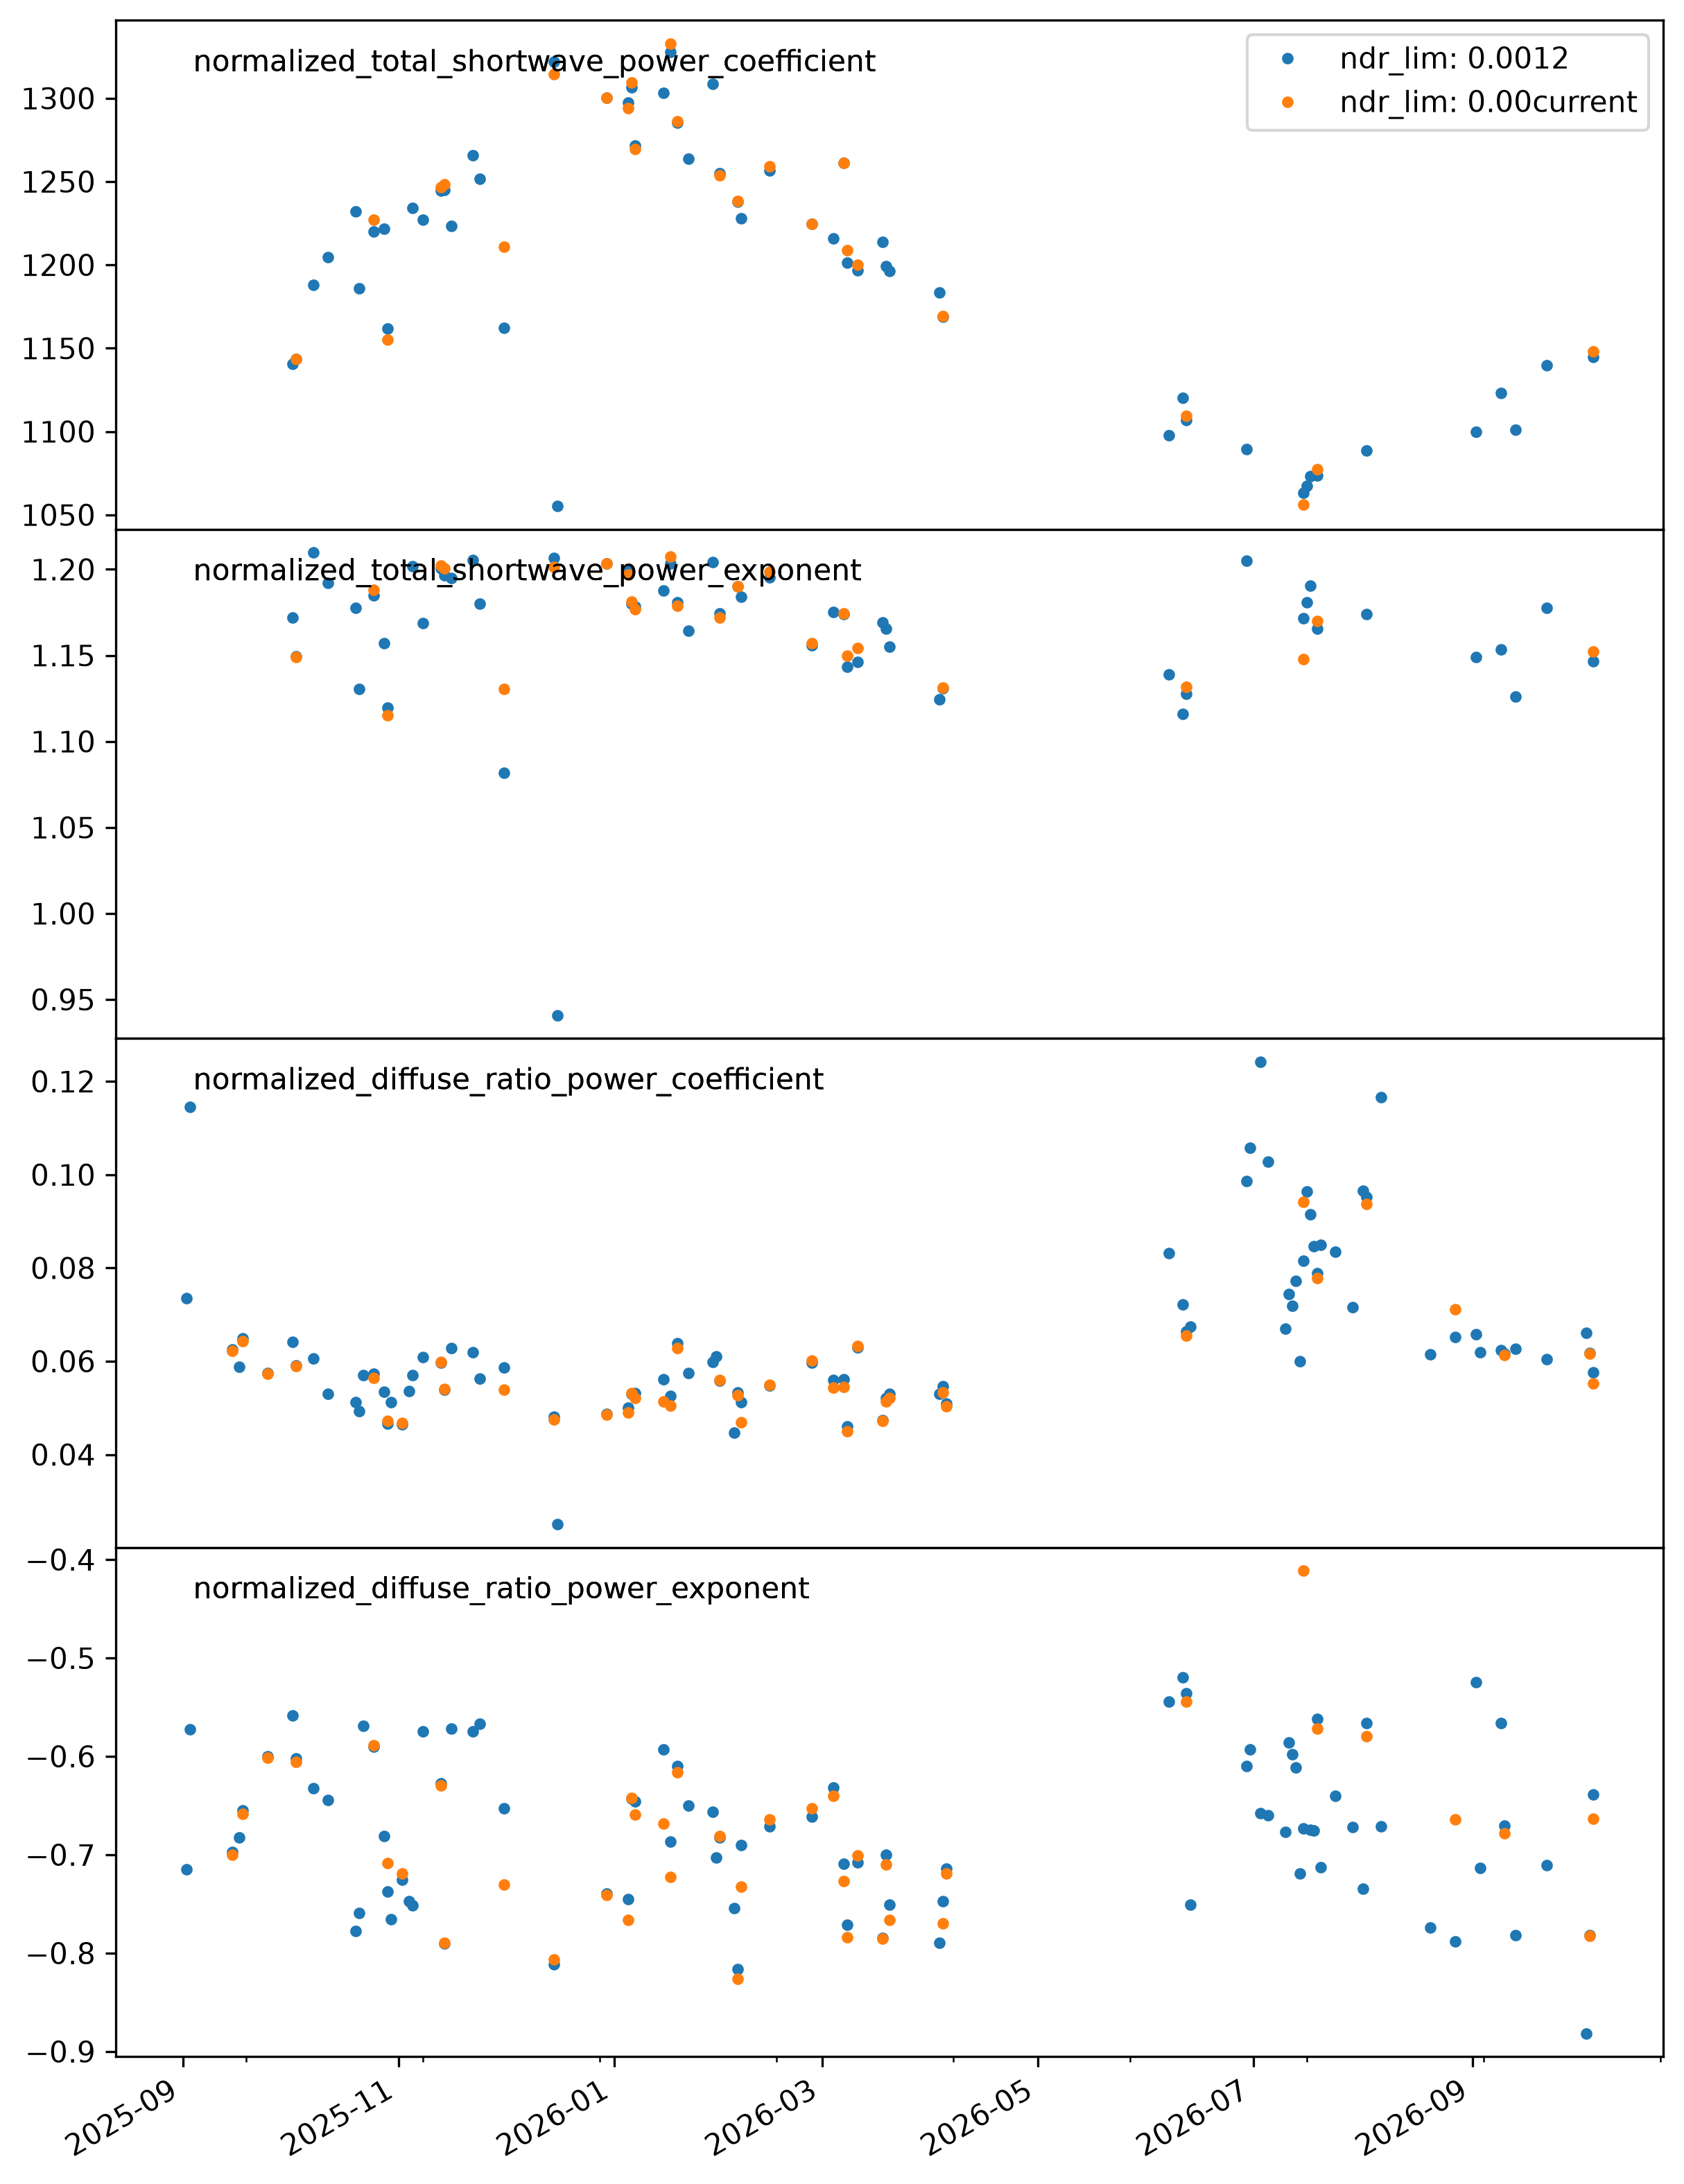

In [142]:
f,aa = plt.subplots(4, sharex= True, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 3)
f.set_figwidth(f.get_figwidth() *1.5)

posn = (0.05, 0.9)
possum = (0.8, 0.9)
names = ['normalized_total_shortwave_power_coefficient',
         'normalized_total_shortwave_power_exponent',
         'normalized_diffuse_ratio_power_coefficient',
         'normalized_diffuse_ratio_power_exponent'
        ]

for dbl in dbs[::-1]:
    df = dbl['data']
    nts_a = df.normalized_total_shortwave_power_coefficient.where(df.normalized_total_shortwave_power_coefficient_is_valid == 1).dropna()
    nts_b = df.normalized_total_shortwave_power_exponent.where(df.normalized_total_shortwave_power_exponent_is_valid == 1).dropna()
    
    ndr_a = df.normalized_diffuse_ratio_power_coefficient.where(df.normalized_diffuse_ratio_power_coefficient_is_valid == 1).dropna()
    ndr_b = df.normalized_diffuse_ratio_power_exponent.where(df.normalized_diffuse_ratio_power_exponent_is_valid == 1).dropna()
    sers = [nts_a, nts_b,ndr_a,ndr_b]
    for e,a in enumerate(aa):
        sers[e].plot(ax = a, ls = '', marker = '.', label = f'ndr_lim: 0.00{dbl["name"]}')
        a.text(posn[0], posn[1], names[e], transform = a.transAxes)
        # a.text(possum[0], possum[1], sers[e].shape[0], transform = a.transAxes)

a = aa[0]
a.legend()


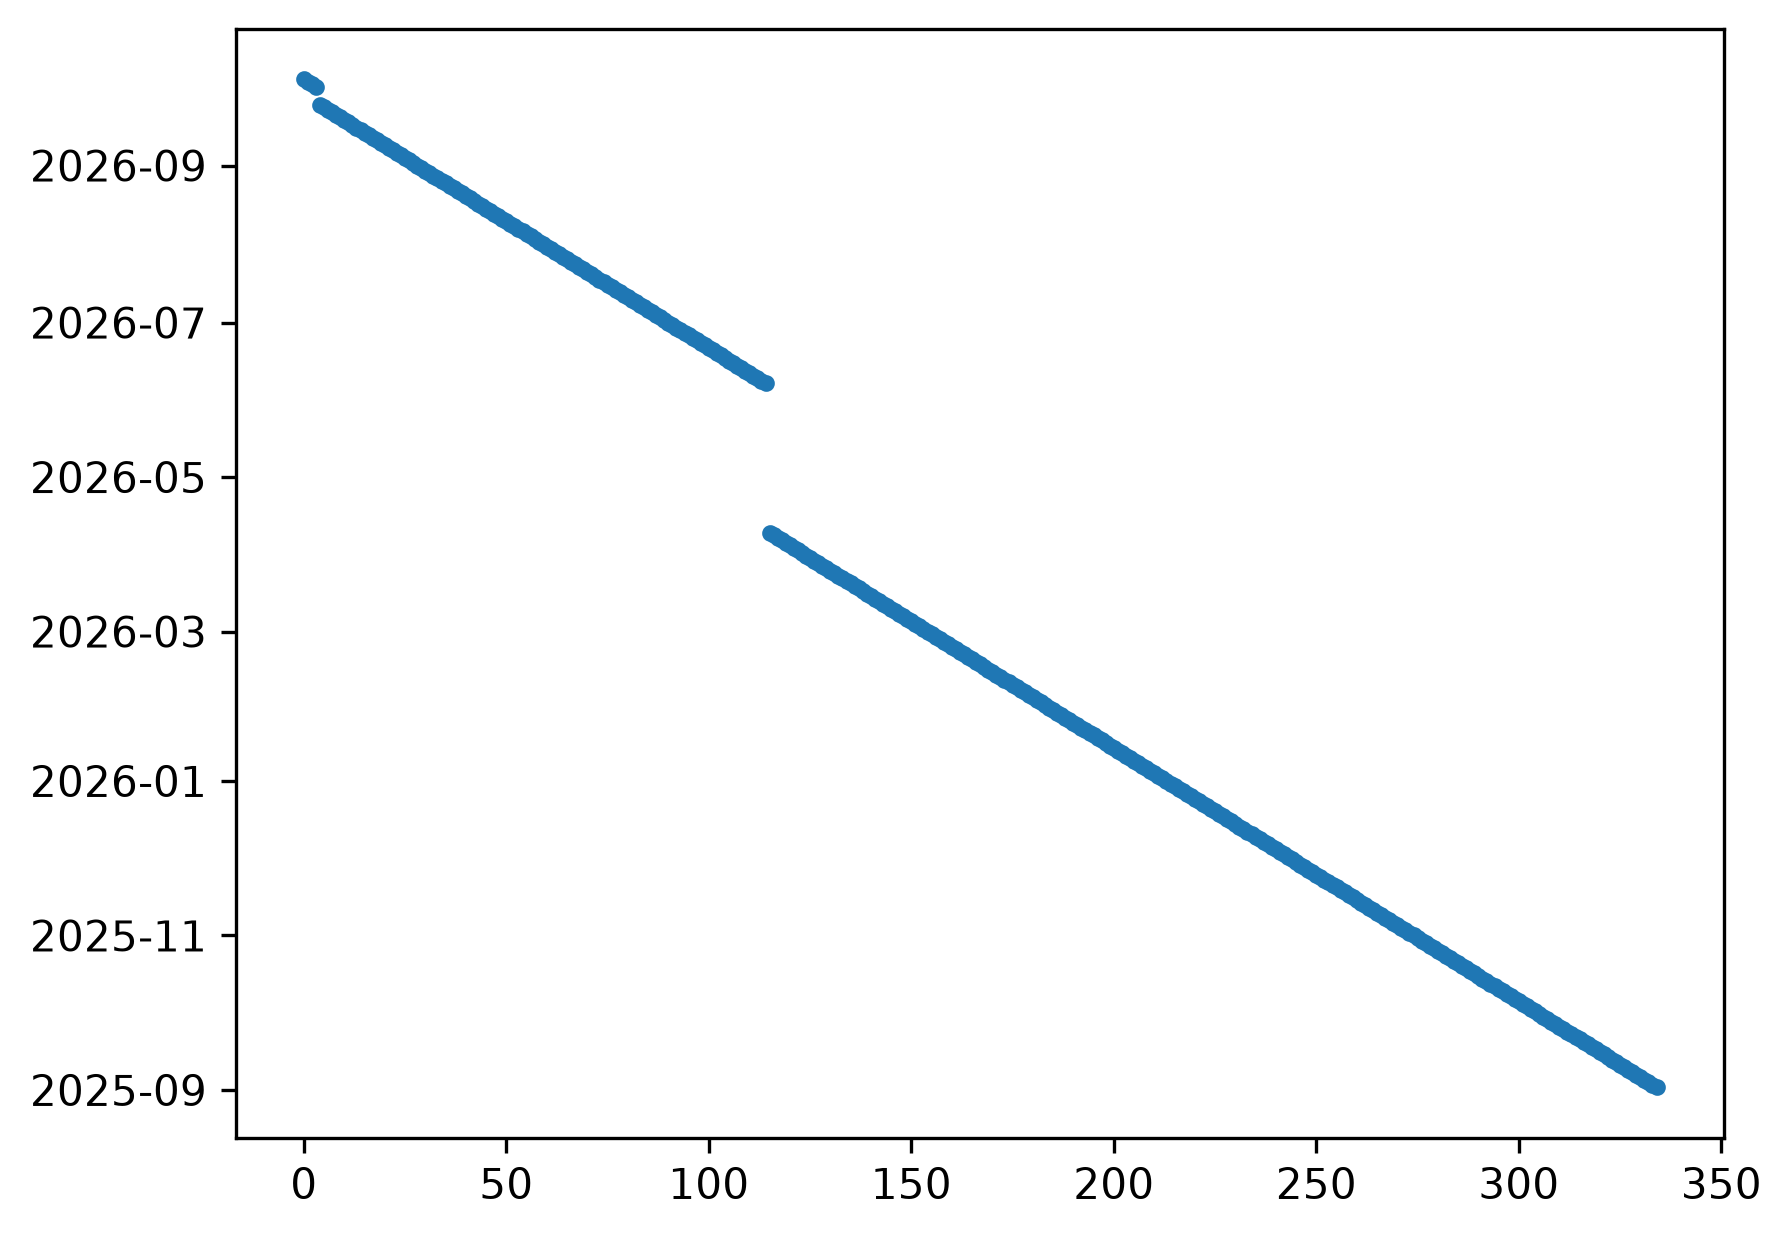

In [131]:
plt.plot(df.index, marker = '.', ls = '')

# radiation2netcdf

## the script

In [56]:
import surfradpy.scripts.clamps3_radiation2netcdf as srfr2nsc

In [87]:
reload(srfr2nsc)
reload(srfr2nsc.srfrad)

<module 'surfradpy.products.radiation2netcdf' from '/Users/htelg/prog/SURFRAD/surfradpy/products/radiation2netcdf.py'>

In [88]:
self = srfr2nsc.run(prefix='/Volumes',  
            start='2025-08-15',
            end=None,
            days=None,
            verbose=True,
            raise_errors=False,
            test=0,
            )

start time: 2026-10-06 17:16:47.811649
Get all files in /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv with "files_between" function and start: 2025-08-15 00:00:00, end: 2026-10-06 17:16:47.848265 and file_name_format: *{date:%Y%m%d}*


Opening input file: [PosixPath('/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/2025/radsys.clamps3-cl3-rad-1m.20250815.csv'), PosixPath('/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/2025/radsys.clamps3-cl3-rad.20250815.csv')]


### the product

In [4]:
import surfradpy.products.radiation2netcdf as srfr2n

In [49]:
si = srfr2n.Clamps3Radiation2netcdf(
    site='clamps3',
    p2fld_in='/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/',
    p2fld_out='/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/netcdf/radiation/v{version}/',
    file_name_format='*{date:%Y%m%d}*',
    output_file_format='clamps_rad_{date}.nc',
    start=None,
    end=None,
    days=20,
    input_directory_structure='yearly',
    reporter=None,
    verbose=True,
)

start time: 2026-10-06 16:45:56.211098


In [50]:
si.workplan
si.process_row(iloc = 0, save = False)

Get all files in /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv with "files_between" function and start: 2026-09-16 16:45:56.211360, end: 2026-10-06 16:45:56.211431 and file_name_format: *{date:%Y%m%d}*
Opening input file: /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/2026/radsys.clamps3-cl3-rad-1m.20260916.csv


<xarray.Dataset> Size: 230kB
Dimensions:                  (datetime: 1439)
Coordinates:
  * datetime                 (datetime) datetime64[us] 12kB 2026-09-16T00:01:...
Data variables: (12/19)
    RECORD                   (datetime) float64 12kB 3.628e+07 ... 3.637e+07
    iService                 (datetime) float64 12kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Vpwr                     (datetime) float64 12kB 13.32 13.32 ... 13.5 13.5
    Tpanel                   (datetime) float64 12kB 29.55 29.45 ... 21.3 21.26
    DW_Global1               (datetime) float64 12kB 61.01 62.67 ... 42.42 42.24
    DW_IR                    (datetime) float64 12kB 334.9 335.6 ... 378.8 377.7
    ...                       ...
    UW_PIR_dome_Temperature  (datetime) float64 12kB nan nan nan ... nan nan nan
    fanSpeedLW               (datetime) float64 12kB 6.312e+03 ... 6.234e+03
    fanSpeedSW               (datetime) float64 12kB 6.125e+03 ... 6.148e+03
    2m_t                     (datetime) float64 12kB 20.61 20.58 ... 17.66 17.65
    2m_rh                    (datetime) float64 12kB 34.69 34.94 ... 71.0 71.34
    bp                       (datetime) float64 12kB 829.3 829.3 ... 832.4 832.4
Attributes:
    parent_files:       /Volumes/grad/gradobs/raw/short_term/clamps3/radsys/s...
    processing_date:    2026-10-06T16:45:56.470846
    processing_server:  telg-mbp.cmdl.noaa.gov
    processing_class:   This file was generated usingsurfradpy.products.radia...
    product_version:    1.1

# read a file

In [52]:
# p2f = '/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/2026/radsys.clamps3-cl3-rad-1m.20260119.csv'
p2f = '/Volumes/grad/gradobs/raw/short_term/clamps3/radsys/scaled/csv/2026/radsys.clamps3-cl3-rad-1m.20260916.csv'
# pd.read_csv(p2f)
srfr2n.read_calmps3(p2f)

<xarray.Dataset> Size: 230kB
Dimensions:                  (datetime: 1439)
Coordinates:
  * datetime                 (datetime) datetime64[us] 12kB 2026-09-16T00:01:...
Data variables: (12/19)
    RECORD                   (datetime) float64 12kB 3.628e+07 ... 3.637e+07
    iService                 (datetime) float64 12kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Vpwr                     (datetime) float64 12kB 13.32 13.32 ... 13.5 13.5
    Tpanel                   (datetime) float64 12kB 29.55 29.45 ... 21.3 21.26
    DW_Global1               (datetime) float64 12kB 61.01 62.67 ... 42.42 42.24
    DW_IR                    (datetime) float64 12kB 334.9 335.6 ... 378.8 377.7
    ...                       ...
    UW_PIR_dome_Temperature  (datetime) float64 12kB nan nan nan ... nan nan nan
    fanSpeedLW               (datetime) float64 12kB 6.312e+03 ... 6.234e+03
    fanSpeedSW               (datetime) float64 12kB 6.125e+03 ... 6.148e+03
    2m_t                     (datetime) float64 12kB 20.61 20.58 ... 17.66 17.65
    2m_rh                    (datetime) float64 12kB 34.69 34.94 ... 71.0 71.34
    bp                       (datetime) float64 12kB 829.3 829.3 ... 832.4 832.4